# Household Asset and Food Security Profiles in an Irrigation Context

## Bill Odiase

Project M4 Submission
B1, Team 1

## Problem Statement: What household profiles emerge based on asset ownership and food availability, and do these profiles differ by irrigation association membership?

## Data Dictionary

| variable | class | description |
|---|---|---|
| key_ID | integer | Added to provide a unique Id for each observation. (The InstanceID field does this as well but it is not as convenient to use) |
| village | character | Village name |
| interview_date | character | Date of interview |
| no_membrs | integer | Number of members in the household |
| years_liv | integer | Number of years living in this village or a neighboring village |
| respondent_wall_type | character | Type of walls the house has |
| rooms | integer | Number of rooms in the main house used for sleeping |
| memb_assoc | character | Are you a member of an irrigation association? |
| affect_conflicts | character | Have you been affected by conflicts with other irrigators in the area? |
| liv_count | integer | Livestock count |
| items_owned | character | Items owned by the household |
| no_meals | integer | How many meals do people in your household normally eat in a day? |
| months_lack_food | character | Indicate which months, in the last 12 months have you faced a situation when you did not have enough food to feed the household? |
| instanceID | character | Unique identifier for the form data submission |

## Loading Data

In [69]:
!pip install yellowbrick
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')
raw_data = pd.read_csv('/content/drive/Othercomputers/My Mac/Github/Unsupervised-and-Unstructured-Machine-Learning/project files/safi_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Preprocessing & Feature Engineering

In [8]:
safi = raw_data.copy()

In [9]:
#fix missing and duplicate responses
safi["memb_assoc"] = safi["memb_assoc"].fillna("unknown").str.lower().str.strip()
safi["affect_conflicts"] = safi["affect_conflicts"].fillna("unknown").str.lower().str.strip()
safi["respondent_wall_type"] = safi["respondent_wall_type"].fillna("unknown").str.lower().str.strip()
safi["items_owned"] = safi["items_owned"].fillna("unknown").str.lower().str.strip()

# split string into list
safi["months_lack_food_list"] = safi["months_lack_food"]
safi["months_lack_food_list"] = safi['months_lack_food_list'].str.strip().str.split(';')

# get the number of months each household experienced food-scarcity
safi['months_lack_food_count'] = safi['months_lack_food_list'].apply(lambda x: len([m for m in x if m.strip() not in ["none", ""]]))

# split string into list
safi["items_owned_list"] = safi["items_owned"]
safi["items_owned_list"] = safi['items_owned_list'].str.strip().str.split(';')

# get the number of items each household reported
safi['items_owned_count'] = safi['items_owned_list'].apply(lambda x: len([i for i in x if i.strip() != "unknown"]))

In [10]:
safi = safi.drop(columns = ["months_lack_food_list", "months_lack_food", "items_owned_list", "items_owned"])
safi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   key_ID                  131 non-null    int64 
 1   village                 131 non-null    object
 2   interview_date          131 non-null    object
 3   no_membrs               131 non-null    int64 
 4   years_liv               131 non-null    int64 
 5   respondent_wall_type    131 non-null    object
 6   rooms                   131 non-null    int64 
 7   memb_assoc              131 non-null    object
 8   affect_conflicts        131 non-null    object
 9   liv_count               131 non-null    int64 
 10  no_meals                131 non-null    int64 
 11  instanceID              131 non-null    object
 12  months_lack_food_count  131 non-null    int64 
 13  items_owned_count       131 non-null    int64 
dtypes: int64(8), object(6)
memory usage: 14.5+ KB


In [11]:
cluster_variables = [
    "no_membrs",
    "liv_count",
    "rooms",
    "no_meals",
    "months_lack_food_count",
    "years_liv",
    "items_owned_count"
]

safi_numeric = safi[cluster_variables].copy()

In [12]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

safi_scaled = pd.DataFrame(
    sc.fit_transform(safi_numeric),
    columns=safi_numeric.columns,
    index=safi_numeric.index
)

# Hierarchical (Ward) - M2 Baseline

**Note:** Profiles are reported in original units for interpretability, but clustering was performed in standardized space to prevent any variable(s) from overpowering

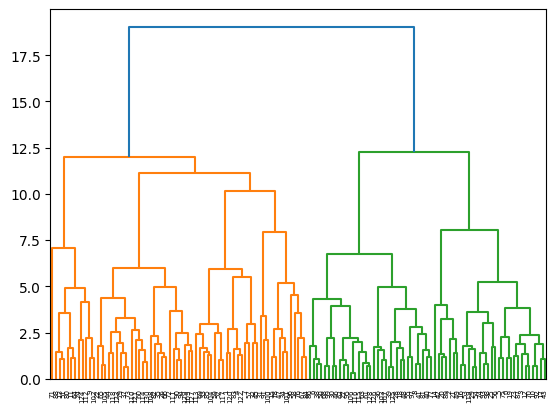

In [13]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(safi_scaled, 'ward')
_ = dendrogram(Z)
plt.grid(False)
plt.show()

In [61]:
ward_labels_k4 = fcluster(Z, t = 4, criterion = "maxclust")

k4_profiles = safi.copy()
k4_profiles["cluster"] = ward_labels_k4

print("Cluster Sizes (k = 4):")
print(k4_profiles["cluster"].value_counts().sort_index())

print("\nCluster Means (k = 4) - Raw Units:")
display(k4_profiles.groupby("cluster")[cluster_variables].mean())

Cluster Sizes (k = 4):
cluster
1    12
2    56
3    33
4    30
Name: count, dtype: int64

Cluster Means (k = 4) - Raw Units:


,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
cluster,,,,,,,
1,9.750000,2.083333,4.000000,2.750000,3.750000,17.500000,5.916667
2,8.160714,3.232143,1.892857,2.660714,1.446429,31.607143,6.607143
3,5.848485,1.515152,1.151515,3.000000,2.242424,15.303030,3.393939
4,5.833333,1.800000,1.200000,2.000000,3.466667,17.833333,2.266667


In [43]:
display(k4_profiles.groupby("cluster")["memb_assoc"].value_counts())

cluster  memb_assoc
1        no             7
         unknown        3
         yes            2
2        no            26
         yes           21
         unknown        9
3        no            16
         unknown       12
         yes            5
4        unknown       15
         no            10
         yes            5
Name: count, dtype: int64


**M2 Baseline Summary**:

In M2, I chose four clusters after inspecting the dendrogram and evaluating natural breaks in the tree. Solutions with fewer than three clusters seemed too vague, while those with more than four began to break clusters into very niche subgroups. A four-cluster solution offered a balanced structure while maintaining interpretability.

The resulting clusters:

• Cluster 1 (n = 12): Larger households with larger homes and relatively high livestock and asset ownership, but also higher food scarcity. These households seem to have many resources, but their size puts more pressure on their consumption.

• Cluster 2 (n = 56): Highest livestock ownership, highest asset counts, longest years in village, and lowest food scarcity. This shows the most economically secure group.

• Cluster 3 (n = 33): Smaller households with lower asset ownership and moderate food vulnerability.

• Cluster 4 (n = 30): Small households have low asset ownership and face significant food scarcity. This group is the most vulnerable.


Membership in irrigation associations was present across all clusters, although Cluster 2 showed the highest proportion of members. Overall, segmentation appeared driven more strongly by assets and food security than by membership status.

## Cluster Number Selection & Defense

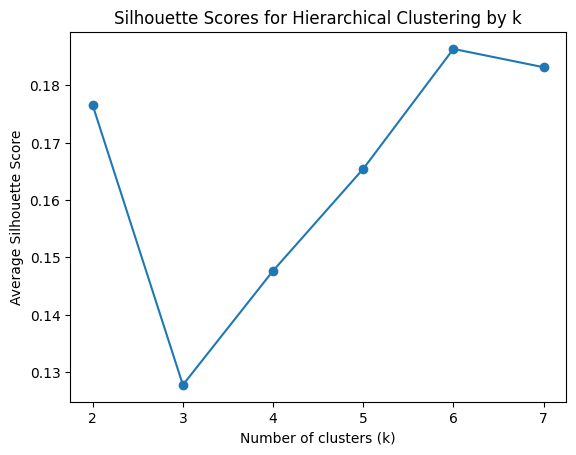

The optimal number of clusters (k) is: 6 (Silhouette score: 0.19)


In [28]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    labels = fcluster(Z, t = k, criterion = "maxclust")
    score = silhouette_score(safi_scaled, labels, metric = "euclidean")
    silhouette_scores.append(score)

plt.plot(k_range, silhouette_scores, marker = "o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Scores for Hierarchical Clustering by k")
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"The optimal number of clusters (k) is: {optimal_k} (Silhouette score: {round(max(silhouette_scores),2)})")

Interpretation:



*   The highest average silhouette score occurs at k = 6 (≈ 0.19). However, all silhouette values fall within a relatively narrow range (approximately 0.13-0.19), suggesting only **modest cluster separation overall**.
*   **Silhouette alone is not enough to choose the final number of clusters.**


To better understand how increasing k affects segmentation, further analysis looks at k = 3 (more straightforward structure) and k = 6 (optimal silhouette). These are compared to the M2 baseline (k = 4) to see whether adding clusters reveals new profiles or just splits existing ones.

In [58]:
ward_labels_k3 = fcluster(Z, t = 3, criterion = "maxclust")

k3_profiles = safi_numeric.copy()
k3_profiles["cluster"] = ward_labels_k3

print("Cluster Sizes (k = 3):")
print(k3_profiles["cluster"].value_counts().sort_index())

print("\nCluster Means (k = 3) - Raw Units:")
display(k3_profiles.groupby("cluster")[cluster_variables].mean())

Cluster Sizes (k = 3):
cluster
1    68
2    33
3    30
Name: count, dtype: int64

Cluster Means (k = 3) - Raw Units:


,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
cluster,,,,,,,
1,8.441176,3.029412,2.264706,2.676471,1.852941,29.117647,6.485294
2,5.848485,1.515152,1.151515,3.000000,2.242424,15.303030,3.393939
3,5.833333,1.800000,1.200000,2.000000,3.466667,17.833333,2.266667


In [62]:
# comparison of k = 3 vs k = 4
k3_vs_k4_count = pd.crosstab(ward_labels_k3, ward_labels_k4,rownames = ["k = 3 cluster"], colnames = ["k = 4 cluster"])
display(k3_vs_k4_count)

k = 4 cluster,1,2,3,4
k = 3 cluster,,,,
1,12,56,0,0
2,0,0,33,0
3,0,0,0,30


Interpretation:

*   Two clusters, sizes 33 and 30, remain unchanged. These clusters represent the lower-asset and more food-vulnerable households.
*   They are also well separated from the rest of the dataset (vulnerable household profiles appear structurally stable across k)
*   Largest cluster, size 68 in k = 3 splits into two groups, sizes 12 and 56, when moving to k = 4.
*   Moving from 3 to 4 clusters mainly splits the higher-asset group into two subtypes rather than introducing a completely new household profile.

In [30]:
ward_labels_k6 = fcluster(Z, t = 6, criterion = "maxclust")

k6_profiles = safi_numeric.copy()
k6_profiles["cluster"] = ward_labels_k6

print("Cluster Sizes (k = 6):")
print(k6_profiles["cluster"].value_counts().sort_index())

print("\nCluster Means (k = 6) - Raw Units:")
display(k6_profiles.groupby("cluster")[cluster_variables].mean())

Cluster Sizes (k = 6):
cluster
1    12
2    26
3    17
4    13
5    33
6    30
Name: count, dtype: int64

Cluster Means (k = 6) - Raw Units:


,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
cluster,,,,,,,
1,9.750000,2.083333,4.000000,2.750000,3.750000,17.500000,5.916667
2,8.307692,3.307692,1.923077,3.000000,1.115385,20.923077,8.500000
3,7.764706,3.000000,2.058824,2.000000,1.647059,28.294118,6.117647
4,8.384615,3.384615,1.615385,2.846154,1.846154,57.307692,3.461538
5,5.848485,1.515152,1.151515,3.000000,2.242424,15.303030,3.393939
6,5.833333,1.800000,1.200000,2.000000,3.466667,17.833333,2.266667


In [51]:
# structural comparison of k = 4 vs k = 6
k4_vs_k6_count = pd.crosstab(ward_labels_k4, ward_labels_k6,rownames = ["k = 4 cluster"], colnames = ["k = 6 cluster"])
display(k4_vs_k6_count)

k = 6 cluster,1,2,3,4,5,6
k = 4 cluster,,,,,,
1,12,0,0,0,0,0
2,0,26,17,13,0,0
3,0,0,0,0,33,0
4,0,0,0,0,0,30


Interpretation:


*   Moving from k = 4 to k = 6, three clusters (sizes 12, 33, and 30) remain unchanged, suggesting these household profiles are structurally stable across different k values
*   The only cluster that continues to divide is the larger middle group (size 56 in k = 4), which splits into three smaller clusters (26, 17, and 13) at k = 6, suggesting this change reflects finer variation within similar households (not entirely new profiles).
*   Raising k beyond 4 mainly adds more detail within one economic group instead of showing truly different household types.

K Selection Decision:

Although the silhouette score is highest at k = 6, the overall values are modest and  the improvement over k = 4 is small. Structural comparison also shows that k = 6 primarily subdivides one larger group rather than identifying new distinct profiles.

Reducing to k = 3 combines two different high-asset groups into one cluster. At k = 4, these households split into high-asset/low-scarcity and high-asset/higher-scarcity profiles. This maintains important differences in food vulnerability that could be hidden otherwise.

Across k = 3 to k = 6, three clusters with sizes 12, 33, and 30 stay structurally stable. However, the 56-observation group at k = 4 has internal variation that breaks apart as k increases. Keeping k = 4 allows us to view this segment as a clear group without dividing it too much, while still keeping important economic differences. Given the balance between structural stability and interpretability, **k = 4 is retained as the final clustering solution**.


## Robustness Checks

### Hierarchical (Average)

In [56]:
Z_avg = linkage(safi_scaled, method="average")

for k in [3, 4, 6]:
    labels_avg = fcluster(Z_avg, t = k, criterion = "maxclust")
    score_avg = silhouette_score(safi_scaled, labels_avg, metric = "euclidean")
    print(f"Average linkage silhouette (k = {k}): {round(score_avg, 2)}")

Average linkage silhouette (k = 3): 0.13
Average linkage silhouette (k = 4): 0.15
Average linkage silhouette (k = 6): 0.19


Interpretation:

*   Average linkage shows a pattern similar to Ward. Silhouette scores go up as k increases, with k = 6 again giving the highest value of 0.19.
*   However, overall magnitude of the scores remains modest.
*  Separation remains moderate, and because the ranking of k does not change across linkage methods, the structural pattern appears stable and not dependent on the linkage choice



### KMeans

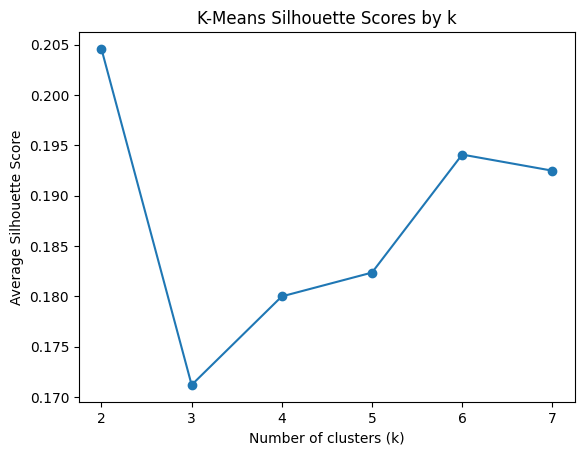

The optimal number of clusters (k) is: 2 (Silhouette score: 0.2)


In [65]:
from sklearn.cluster import KMeans

k_means_range = range(2, 8)
kmeans_silhouettes = []

for k in k_range:
    kmeans_model = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans_labels = kmeans_model.fit_predict(safi_scaled)
    score = silhouette_score(safi_scaled, kmeans_labels, metric = "euclidean")
    kmeans_silhouettes.append(score)

plt.plot(list(k_range), kmeans_silhouettes, marker = "o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.title("K-Means Silhouette Scores by k")
plt.show()



optimal_k_means = k_means_range[np.argmax(kmeans_silhouettes)]
print(f"The optimal number of clusters (k) is: {optimal_k_means} (Silhouette score: {round(max(kmeans_silhouettes),2)})")



*   Although K-Means silhouette peaks at k = 2, this solution would merge distinct subgroups that have economic significance.

/usr/local/lib/python3.12/dist-packages/yellowbrick/utils/kneed.py:156: YellowbrickWarning: No 'knee' or 'elbow point' detected This could be due to bad clustering, no actual clusters being formed etc.
  warnings.warn(warning_message, YellowbrickWarning)
/usr/local/lib/python3.12/dist-packages/yellowbrick/cluster/elbow.py:374: YellowbrickWarning: No 'knee' or 'elbow' point detected, pass `locate_elbow=False` to remove the warning
  warnings.warn(warning_message, YellowbrickWarning)


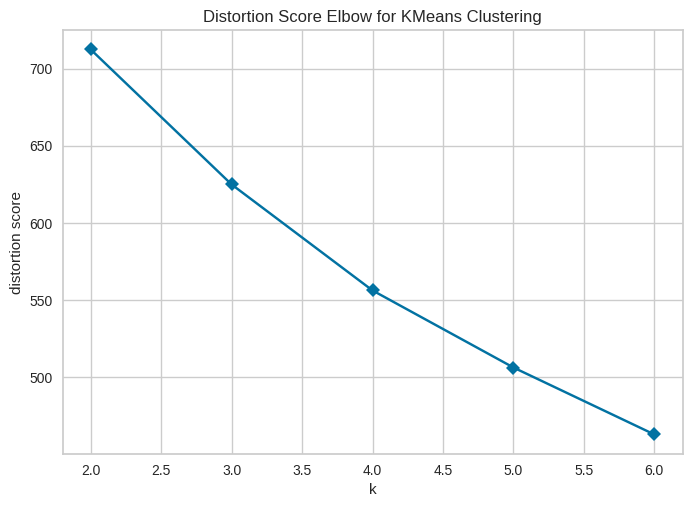

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [70]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

kmeans_model = KMeans(random_state=42, n_init=10)

elbow_viz = KElbowVisualizer(
    kmeans_model,
    k=(2, 7),
    metric="distortion",
    timings=False
)

elbow_viz.fit(safi_scaled)
elbow_viz.show()

### Adjusted Rand Score

In [76]:
from sklearn.metrics import adjusted_rand_score

chosen_k = 4

# Hierarchical labels
ward_labels = fcluster(Z, t=chosen_k, criterion="maxclust")
avg_labels = fcluster(Z_avg, t=chosen_k, criterion="maxclust")

# KMeans labels
km = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
kmeans_labels = km.fit_predict(safi_scaled)

ari_km_ward = adjusted_rand_score(kmeans_labels, ward_labels)
ari_km_avg = adjusted_rand_score(kmeans_labels, avg_labels)

print(f"ARI (K-Means vs Ward) at k = {chosen_k}: {ari_km_ward:.3f}")
print(f"ARI (K-Means vs Average) at k = {chosen_k}: {ari_km_avg:.3f}")

ARI (K-Means vs Ward) at k = 4: 0.449
ARI (K-Means vs Average) at k = 4: 0.028


Interpretation:

*   At k = 4, the ARI between K-Means and Ward (0.449) shows moderate agreement, suggesting the segmentation is reasonably consistent across methods.
*   ARI between K-Means and Average linkage is near zero (0.028), indicating little agreement. This suggests that Average linkage produces a structurally different segmentation and may be unstable with this dataset.
*   Overall, the moderate agreement between Ward and K-Means strengthens confidence in the k = 4.

### Comparison of Methods' Cluster Sizes

In [74]:
print("Ward Cluster Sizes (k = 4):")
display(pd.Series(ward_labels).value_counts().sort_index())

Ward Cluster Sizes (k = 4):


,count
1,12
2,56
3,33
4,30


In [77]:
print("Average Linkage Cluster Sizes (k = 4):")
display(pd.Series(avg_labels).value_counts().sort_index())

Average Linkage Cluster Sizes (k = 4):


,count
1,123
2,6
3,1
4,1


In [78]:
print("K-Means Cluster Sizes (k = 4):")
display(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Cluster Sizes (k = 4):


,count
0,35
1,22
2,39
3,35


Interpretation:

*  At k = 4, Ward produces a balanced segmentation with one larger group (56)
and three smaller but stable clusters (12, 33, and 30). K-Means produces relatively balanced (although different) cluster sizes, suggesting comparable structure across methods.

*  Average linkage combines most observations into one cluster (123), indicating weak separation. The stronger connection between Ward and K-Means boosts confidence in the k = 4 solution.